In [161]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from torchsummary import summary
import matplotlib.pyplot as plt
import numpy as np

In [162]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [163]:
from google.colab import files
uploaded = files.upload()

Saving Assignment1_regression_dataset.csv to Assignment1_regression_dataset (7).csv


In [164]:
import pandas as pd

df = pd.read_csv("/content/Assignment1_regression_dataset.csv")  # Replace with your actual file name
print(df.head())  # Display first few rows

   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0   0.237217   1.036330  -0.532389  -1.533744   0.440671   0.950129   
1   0.331479  -0.606214  -1.810826   1.692943   0.845995  -0.257764   
2  -2.286173   0.336385  -0.222143   0.275975   1.594667  -0.964832   
3   0.571601  -0.952934   1.135237  -1.644562   0.683982  -1.875331   
4  -0.244943   0.765832  -0.193775   1.541691   0.422582   0.500829   

   feature_6  feature_7  feature_8  feature_9  ...  feature_12  feature_13  \
0  -1.004601  -1.288407  -0.485004  -0.530691  ...    1.096084   -0.685087   
1   1.043425  -1.400844   0.892531   1.093124  ...    1.318731   -0.158003   
2  -2.516590  -1.963036  -1.103141  -0.741343  ...   -0.896346    0.508038   
3   0.659725   1.380425  -2.329484  -0.008463  ...   -0.751929    0.101200   
4  -1.760890  -2.803476   0.437787  -0.727198  ...    0.838041   -0.573561   

   feature_14  feature_15  feature_16  feature_17  feature_18  feature_19  \
0   -1.097870   -0.259732  

**Task-1**

In [165]:
# Separate features and targets
X = df.iloc[:, :-2].values  # All features
Y = df.iloc[:, -2:].values  # Target columns

# Standardize the features for better training stability
scaler = StandardScaler()
scaler_Y = StandardScaler()
X = scaler.fit_transform(X)
Y = scaler_Y.fit_transform(Y)

# Split dataset into training (70%) and temp (30%)
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

# Further split temp dataset into validation (15%) and test (15%)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# Convert to PyTorch tensors and move to device
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
Y_val_tensor = torch.tensor(Y_val, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32).to(device)

# Create TensorDatasets
dataset_train = TensorDataset(X_train_tensor, Y_train_tensor)
dataset_val = TensorDataset(X_val_tensor, Y_val_tensor)
dataset_test = TensorDataset(X_test_tensor, Y_test_tensor)

# Define batch size
batch_size = 32

# Create DataLoaders
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)
dataloader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

print("Data split and DataLoaders created successfully!")

Data split and DataLoaders created successfully!


**Task-2**

In [166]:
# Define Fully Connected Neural Network (FCNN) for regression with cross-validation
class FCNN(nn.Module):
    def __init__(self, input_size, output_size):
        super(FCNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 32)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(32, output_size)
        self.output_activation = nn.Identity()  # No activation for regression

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        x = self.output_activation(x)
        return x

# Initialize model and move to device
input_size = X_train.shape[1]
output_size = Y_train.shape[1]
model = FCNN(input_size, output_size).to(device)
# Xavier initialization for stability
def init_weights(m):
  if isinstance(m, nn.Linear):
    nn.init.xavier_uniform_(m.weight)
    if m.bias is not None:
      nn.init.zeros_(m.bias)
model.apply(init_weights)

print("Fully Connected Neural Network (FCNN) initialized with optimized architecture!")

Fully Connected Neural Network (FCNN) initialized with optimized architecture!


**Task-3**

In [167]:
# Print model summary
summary(model, input_size=(batch_size, input_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1              [-1, 32, 128]           2,688
              ReLU-2              [-1, 32, 128]               0
            Linear-3               [-1, 32, 64]           8,256
              ReLU-4               [-1, 32, 64]               0
            Linear-5               [-1, 32, 32]           2,080
              ReLU-6               [-1, 32, 32]               0
            Linear-7                [-1, 32, 2]              66
          Identity-8                [-1, 32, 2]               0
Total params: 13,090
Trainable params: 13,090
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.11
Params size (MB): 0.05
Estimated Total Size (MB): 0.16
----------------------------------------------------------------


**Task-4**

In [168]:
# Define loss function (Mean Squared Error for regression)
criterion = nn.MSELoss()

**Task-5 (Training Process)**

In [199]:
# Define optimizer (SGD with initial learning rate)
learning_rate = 0.01
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [200]:
# Experiment with different batch sizes
batch_sizes = [16,64]

for batch_size in batch_sizes:
    print(f"Training with batch size: {batch_size}")

    # Create DataLoaders
    dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)
    dataloader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

    # Initialize model and move to device
    model = FCNN(input_size, output_size).to(device)

    # Define optimizer (SGD with initial learning rate)
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    # Print model summary
    summary(model, input_size=(batch_size, input_size))

Training with batch size: 16
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1              [-1, 16, 128]           2,688
              ReLU-2              [-1, 16, 128]               0
            Linear-3               [-1, 16, 64]           8,256
              ReLU-4               [-1, 16, 64]               0
            Linear-5               [-1, 16, 32]           2,080
              ReLU-6               [-1, 16, 32]               0
            Linear-7                [-1, 16, 2]              66
          Identity-8                [-1, 16, 2]               0
Total params: 13,090
Trainable params: 13,090
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.05
Estimated Total Size (MB): 0.11
----------------------------------------------------------------
Training with b

In [201]:
# Define learning rate scheduler to reduce LR when validation loss stagnates
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [202]:
# Check for NaN values in the dataset
if np.isnan(X).sum() > 0 or np.isnan(Y).sum() > 0:
    raise ValueError("Dataset contains NaN values. Please clean the data.")

In [203]:
# Training loop with loss tracking
num_epochs = 50
train_losses = []
val_losses = []

for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0
  for X_batch, Y_batch in dataloader_train:
    optimizer.zero_grad()
    outputs = model(X_batch)

    # Check for NaN values before computing loss
    if torch.isnan(outputs).sum() > 0:
      raise ValueError("NaN detected in model outputs! Check network stability.")

    loss = criterion(outputs, Y_batch)
    if torch.isnan(loss):
      raise ValueError("NaN detected in loss! Check input data and model stability.")

    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  train_loss = running_loss / len(dataloader_train)
  train_losses.append(train_loss)

  # Validation loss
  model.eval()
  val_loss = 0.0
  with torch.no_grad():
    for X_batch, Y_batch in dataloader_val:
      outputs = model(X_batch)
      loss = criterion(outputs, Y_batch)
      val_loss += loss.item()
    val_loss /= len(dataloader_val)
    val_losses.append(val_loss)

  # Step the scheduler
  scheduler.step(val_loss)

  print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


Epoch 1/50 - Train Loss: 1.0066, Val Loss: 1.0666
Epoch 2/50 - Train Loss: 0.9914, Val Loss: 1.0648
Epoch 3/50 - Train Loss: 0.9821, Val Loss: 1.0636
Epoch 4/50 - Train Loss: 0.9742, Val Loss: 1.0624
Epoch 5/50 - Train Loss: 0.9650, Val Loss: 1.0610
Epoch 6/50 - Train Loss: 0.9590, Val Loss: 1.0589
Epoch 7/50 - Train Loss: 0.9547, Val Loss: 1.0562
Epoch 8/50 - Train Loss: 0.9461, Val Loss: 1.0528
Epoch 9/50 - Train Loss: 0.9401, Val Loss: 1.0484
Epoch 10/50 - Train Loss: 0.9323, Val Loss: 1.0427
Epoch 11/50 - Train Loss: 0.9249, Val Loss: 1.0357
Epoch 12/50 - Train Loss: 0.9153, Val Loss: 1.0276
Epoch 13/50 - Train Loss: 0.9050, Val Loss: 1.0173
Epoch 14/50 - Train Loss: 0.8953, Val Loss: 1.0058
Epoch 15/50 - Train Loss: 0.8819, Val Loss: 0.9911
Epoch 16/50 - Train Loss: 0.8662, Val Loss: 0.9740
Epoch 17/50 - Train Loss: 0.8498, Val Loss: 0.9534
Epoch 18/50 - Train Loss: 0.8289, Val Loss: 0.9299
Epoch 19/50 - Train Loss: 0.8040, Val Loss: 0.9013
Epoch 20/50 - Train Loss: 0.7785, Val Lo

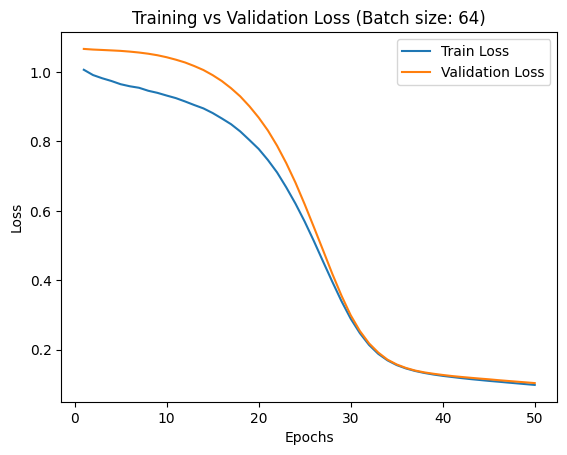

In [204]:
# Plot training and validation loss
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title(f'Training vs Validation Loss (Batch size: {batch_size})')
plt.show()

**Task-6**

In [205]:
from torch.utils.tensorboard import SummaryWriter

In [206]:
# Initialize TensorBoard writer
writer = SummaryWriter()

In [207]:
# Training loop with loss tracking
num_epochs = 50
train_losses = []
val_losses = []

for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0
  for X_batch, Y_batch in dataloader_train:
    optimizer.zero_grad()
    outputs = model(X_batch)

    # Check for NaN values before computing loss
    if torch.isnan(outputs).sum() > 0:
      raise ValueError("NaN detected in model outputs! Check network stability.")

    loss = criterion(outputs, Y_batch)
    if torch.isnan(loss):
      raise ValueError("NaN detected in loss! Check input data and model stability.")

    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  train_loss = running_loss / len(dataloader_train)
  train_losses.append(train_loss)

  # Validation loss
  model.eval()
  val_loss = 0.0
  with torch.no_grad():
    for X_batch, Y_batch in dataloader_val:
      outputs = model(X_batch)
      loss = criterion(outputs, Y_batch)
      val_loss += loss.item()
    val_loss /= len(dataloader_val)
    val_losses.append(val_loss)

  # Log losses to TensorBoard
  writer.add_scalar("Loss/Train", train_loss, epoch)
  writer.add_scalar("Loss/Validation", val_loss, epoch)

  # Step the scheduler
  scheduler.step(val_loss)

  print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


Epoch 1/50 - Train Loss: 0.0964, Val Loss: 0.1017
Epoch 2/50 - Train Loss: 0.0941, Val Loss: 0.0995
Epoch 3/50 - Train Loss: 0.0918, Val Loss: 0.0972
Epoch 4/50 - Train Loss: 0.0894, Val Loss: 0.0950
Epoch 5/50 - Train Loss: 0.0872, Val Loss: 0.0928
Epoch 6/50 - Train Loss: 0.0851, Val Loss: 0.0905
Epoch 7/50 - Train Loss: 0.0826, Val Loss: 0.0882
Epoch 8/50 - Train Loss: 0.0803, Val Loss: 0.0861
Epoch 9/50 - Train Loss: 0.0781, Val Loss: 0.0838
Epoch 10/50 - Train Loss: 0.0757, Val Loss: 0.0817
Epoch 11/50 - Train Loss: 0.0734, Val Loss: 0.0796
Epoch 12/50 - Train Loss: 0.0711, Val Loss: 0.0775
Epoch 13/50 - Train Loss: 0.0688, Val Loss: 0.0755
Epoch 14/50 - Train Loss: 0.0667, Val Loss: 0.0735
Epoch 15/50 - Train Loss: 0.0645, Val Loss: 0.0714
Epoch 16/50 - Train Loss: 0.0625, Val Loss: 0.0694
Epoch 17/50 - Train Loss: 0.0604, Val Loss: 0.0674
Epoch 18/50 - Train Loss: 0.0583, Val Loss: 0.0655
Epoch 19/50 - Train Loss: 0.0563, Val Loss: 0.0635
Epoch 20/50 - Train Loss: 0.0543, Val Lo

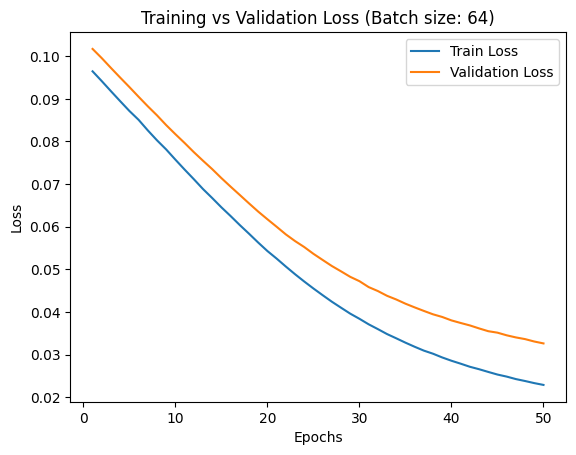

In [208]:
# Plot training and validation loss
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title(f'Training vs Validation Loss (Batch size: {batch_size})')
plt.show()

In [209]:
# Close TensorBoard writer
writer.close()

**Task-7**

In [210]:
# Save the trained model
model_path = f"fcnn_model_batch{batch_size}.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to fcnn_model_batch64.pth


**Task-8**

In [211]:
from sklearn.metrics import mean_squared_error

In [212]:
# Load the trained model
best_model_path = "fcnn_model_batch64.pth"  # Change as needed
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

# Perform predictions on the test set
with torch.no_grad():
    predictions = model(X_test_tensor)

# Convert predictions and targets back to original scale
predictions = scaler_Y.inverse_transform(predictions.cpu().numpy())
Y_test_actual = scaler_Y.inverse_transform(Y_test_tensor.cpu().numpy())

# Compute and report MSE
mse = mean_squared_error(Y_test_actual, predictions)
print(f"Mean Squared Error on Test Data: {mse:.4f}")

Mean Squared Error on Test Data: 1311.1719


<ipython-input-212-6a4008b8d2d7>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


**Task-9**

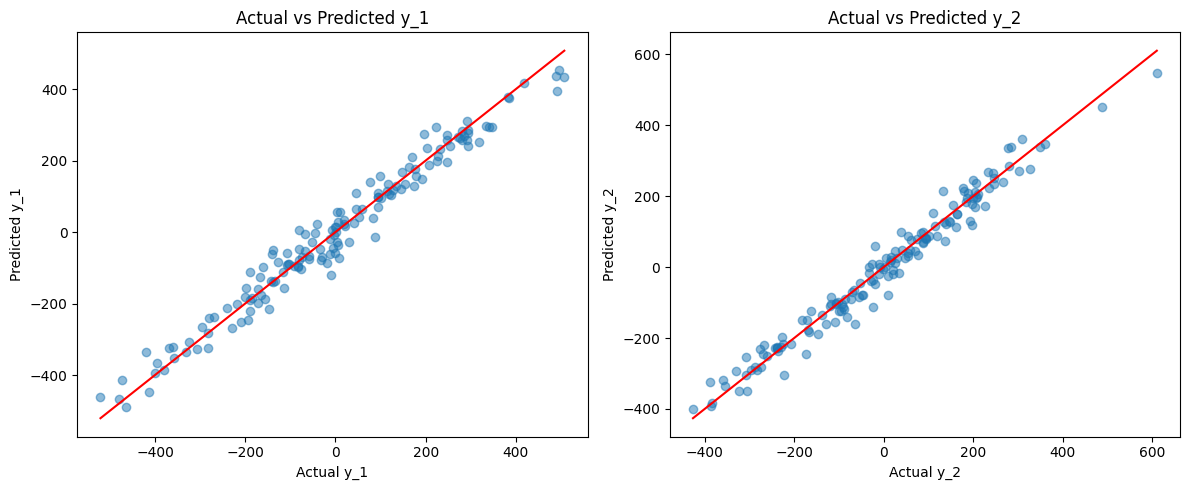

In [213]:
# Scatter plots for predicted vs actual values
plt.figure(figsize=(12, 5))

# Scatter plot for y_1
plt.subplot(1, 2, 1)
plt.scatter(Y_test_actual[:, 0], predictions[:, 0], alpha=0.5)
plt.xlabel("Actual y_1")
plt.ylabel("Predicted y_1")
plt.title("Actual vs Predicted y_1")
plt.plot([min(Y_test_actual[:, 0]), max(Y_test_actual[:, 0])], [min(Y_test_actual[:, 0]), max(Y_test_actual[:, 0])], 'r')

# Scatter plot for y_2
plt.subplot(1, 2, 2)
plt.scatter(Y_test_actual[:, 1], predictions[:, 1], alpha=0.5)
plt.xlabel("Actual y_2")
plt.ylabel("Predicted y_2")
plt.title("Actual vs Predicted y_2")
plt.plot([min(Y_test_actual[:, 1]), max(Y_test_actual[:, 1])], [min(Y_test_actual[:, 1]), max(Y_test_actual[:, 1])], 'r')

plt.tight_layout()
plt.show()